# Estudio de Hiperesferas: Volumen y Propiedades Geométricas en Dimensiones Altas

Thanos Drossos

Este proyecto investiga las propiedades geométricas de las esferas n-dimensionales (hiperesferas) al aumentar la dimensión. Analizamos cómo cambia el volumen total, encontrando que alcanza un máximo sorprendente alrededor de la dimensión 5.24 antes de decrecer exponencialmente. 

Examinamos también el fenómeno del "desplazamiento hacia la corteza": a medida que la dimensión aumenta, una proporción cada vez mayor del volumen se concentra en la región exterior o "corteza". En dimensiones muy altas (>100), prácticamente todo el volumen (>99%) se encuentra en esta capa exterior.

Adicionalmente, estudiamos la relación volumen-superficie, que se aproxima asintóticamente a r/n cuando n aumenta, confirmando propiedades fundamentales de la geometría en altas dimensiones.

Dimension 2:
  Total volume: 3.141593e+00
  Crust volume: 6.251769e-02
  Ratio: 0.019900 (1.9900%)

Dimension 3:
  Total volume: 4.188790e+00
  Crust volume: 1.244113e-01
  Ratio: 0.029701 (2.9701%)

Dimension 4:
  Total volume: 4.934802e+00
  Crust volume: 1.944509e-01
  Ratio: 0.039404 (3.9404%)

Dimension 5:
  Total volume: 5.263789e+00
  Crust volume: 2.579780e-01
  Ratio: 0.049010 (4.9010%)

Dimension 10:
  Total volume: 2.550164e+00
  Crust volume: 2.438414e-01
  Ratio: 0.095618 (9.5618%)

Dimension 20:
  Total volume: 2.580689e-02
  Crust volume: 4.699256e-03
  Ratio: 0.182093 (18.2093%)

Dimension 40:
  Total volume: 3.604731e-09
  Crust volume: 1.193268e-09
  Ratio: 0.331028 (33.1028%)

Dimension 50:
  Total volume: 1.730219e-13
  Crust volume: 6.834261e-14
  Ratio: 0.394994 (39.4994%)

Dimension 100:
  Total volume: 2.368202e-40
  Crust volume: 1.501364e-40
  Ratio: 0.633968 (63.3968%)

Dimension 200:
  Total volume: 5.558833e-109
  Crust volume: 4.814062e-109
  Ratio: 0.8660

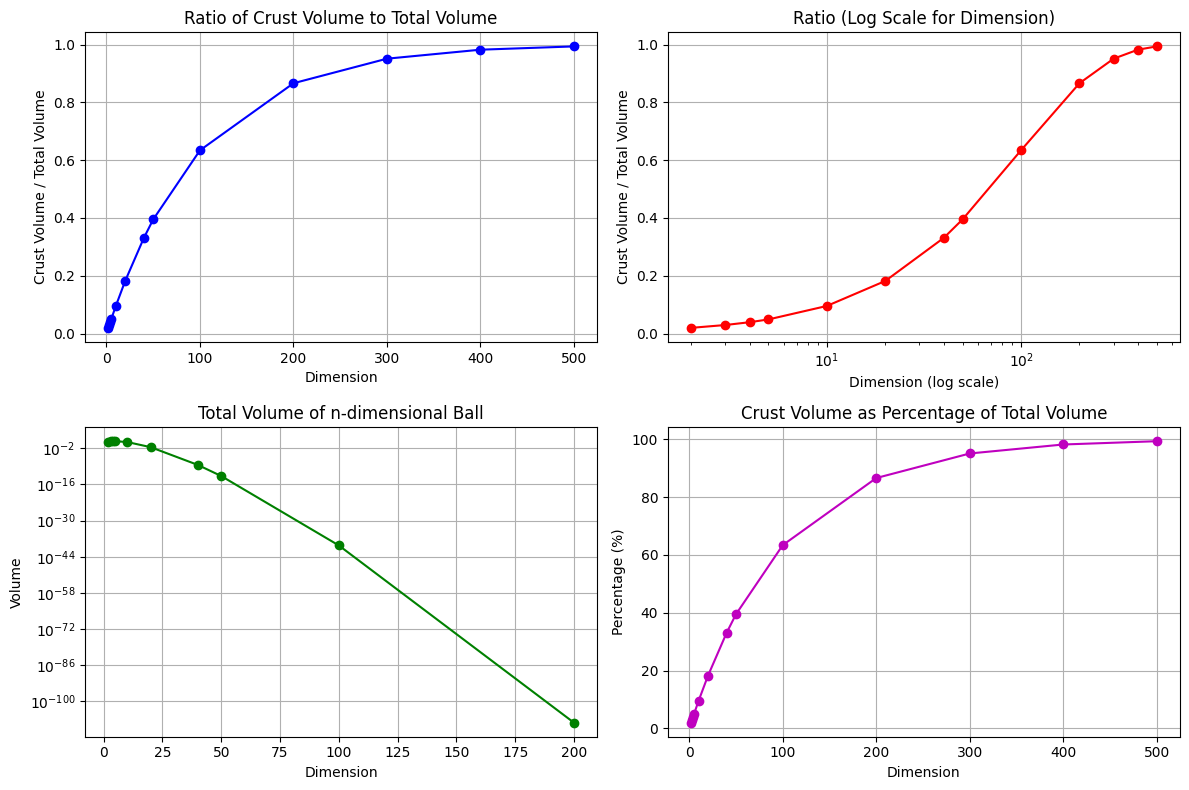

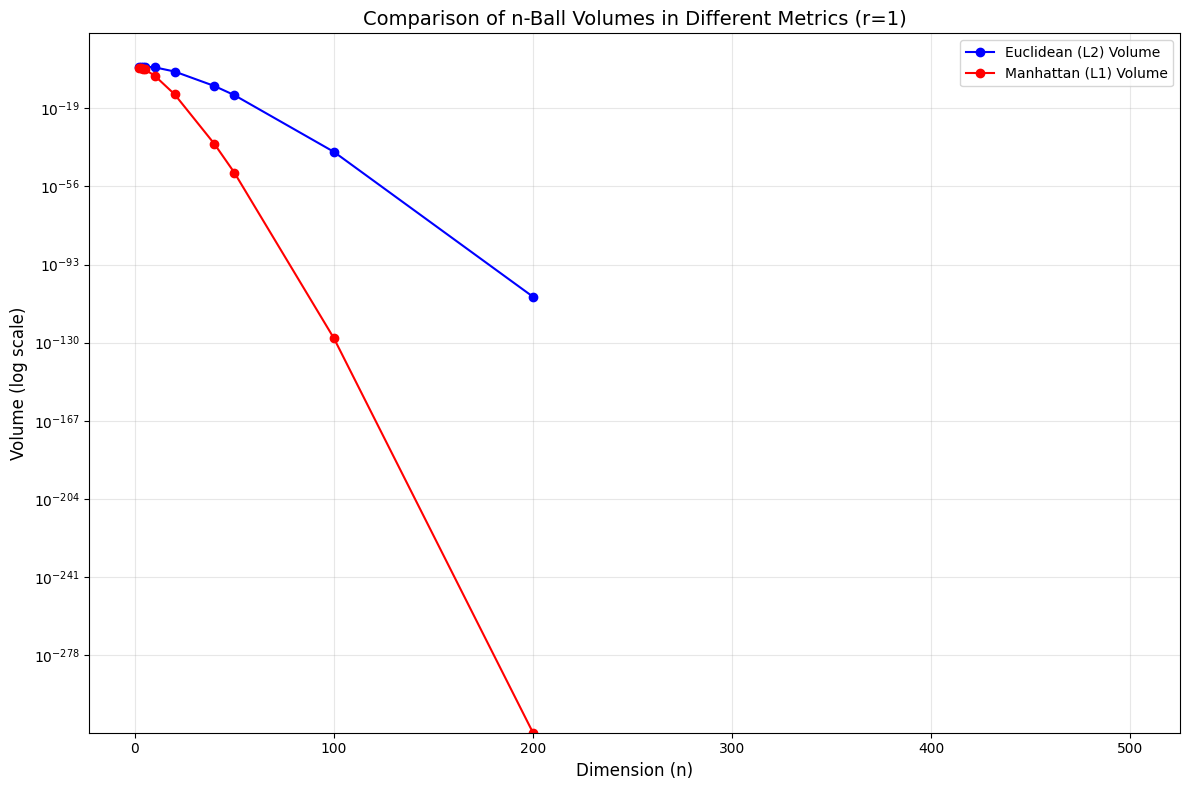

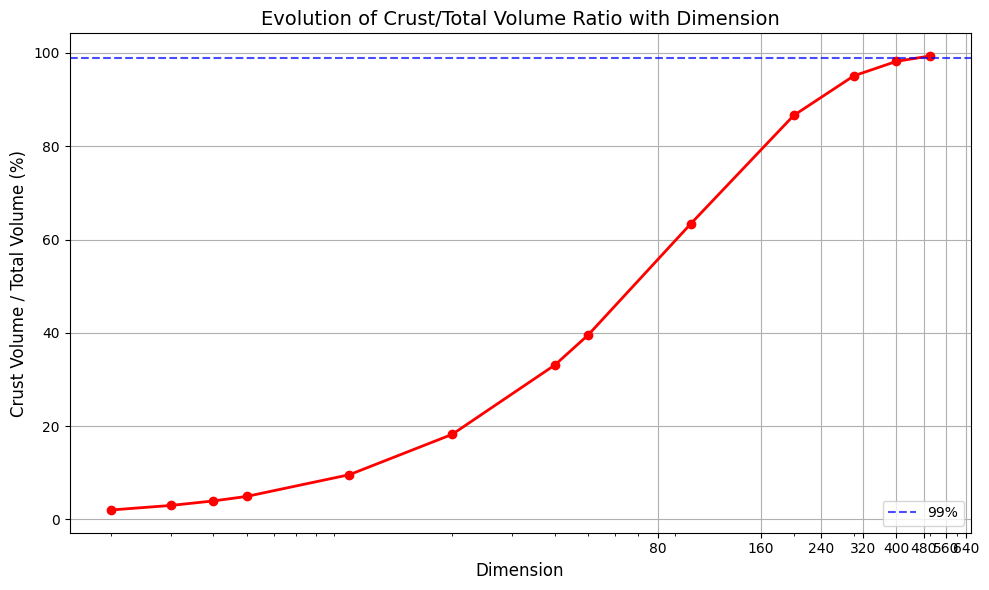

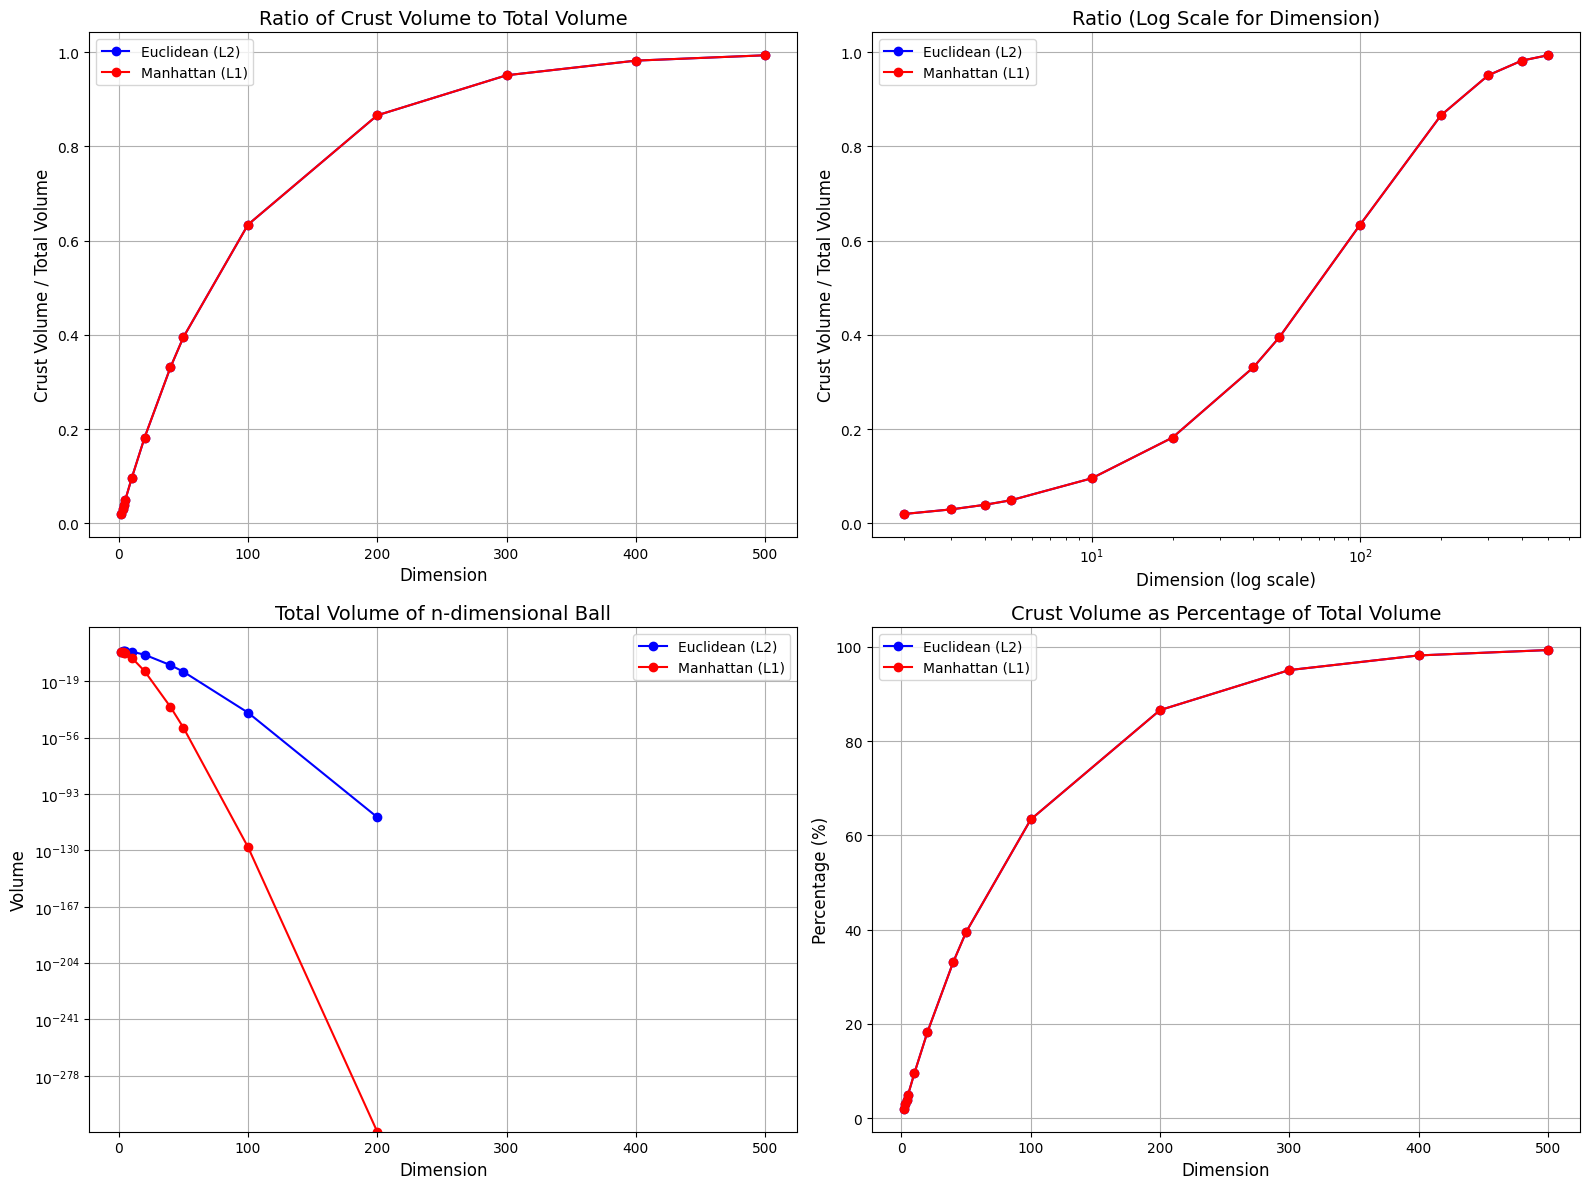

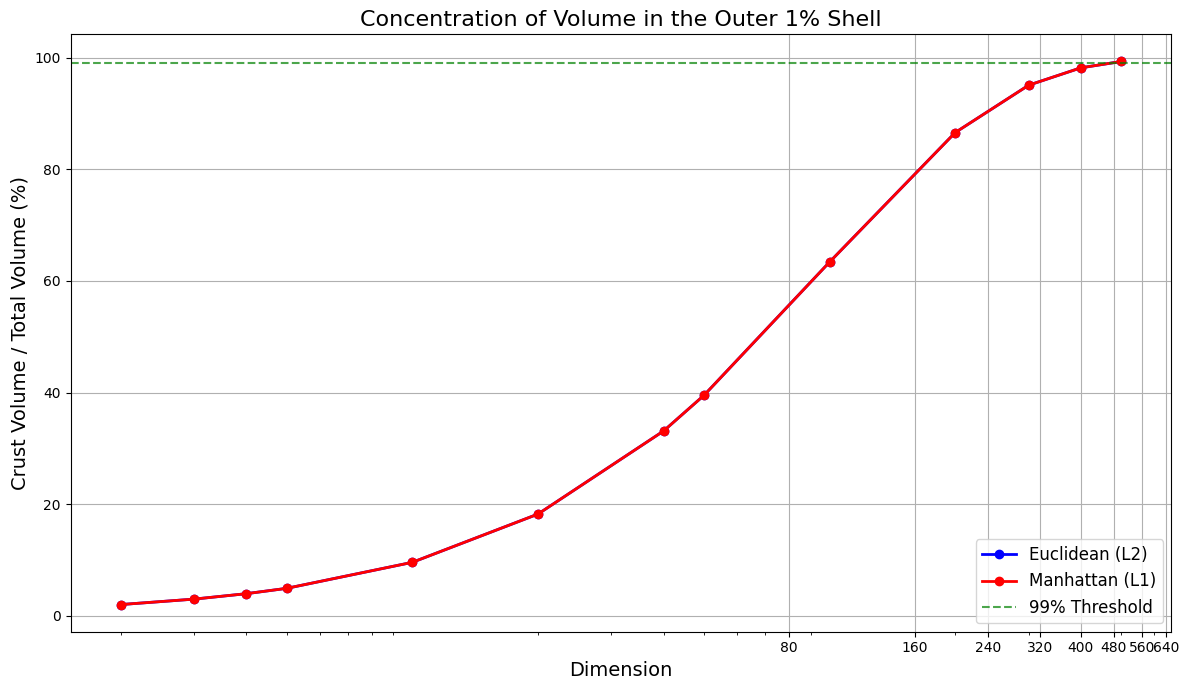

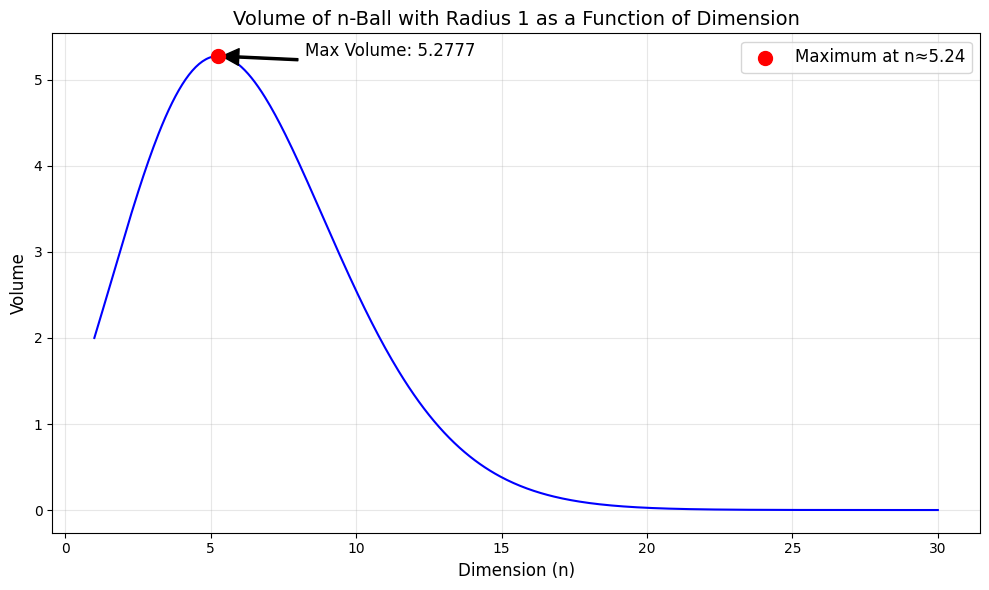

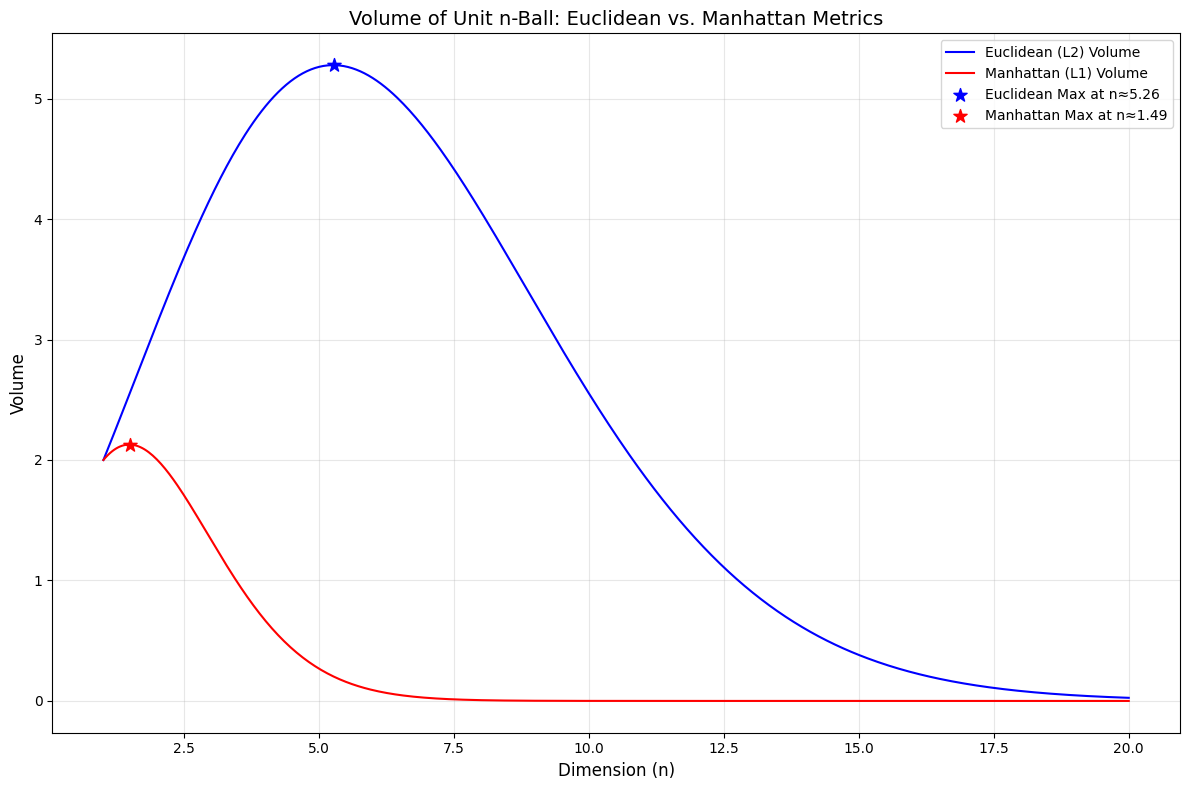

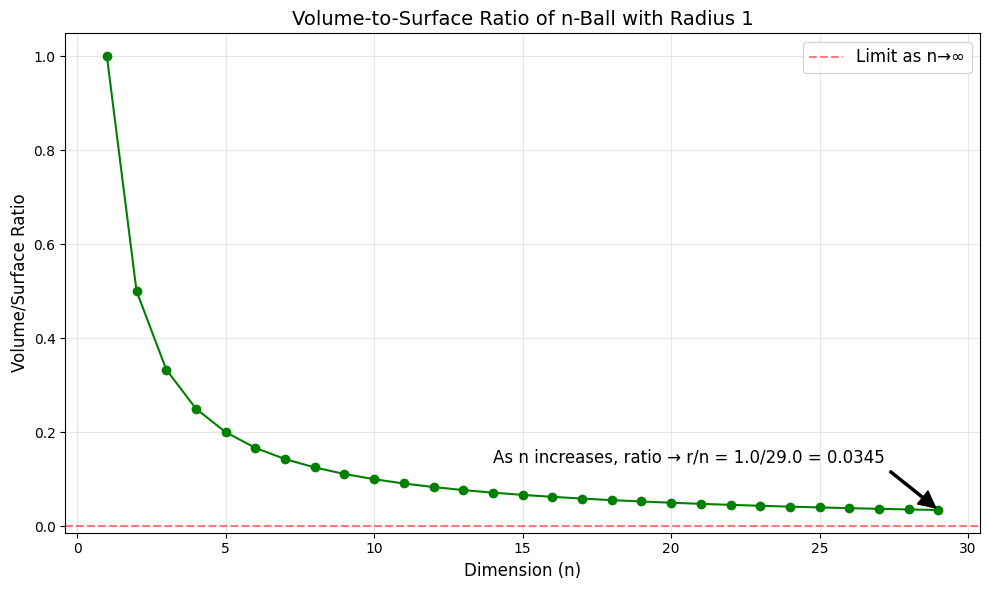

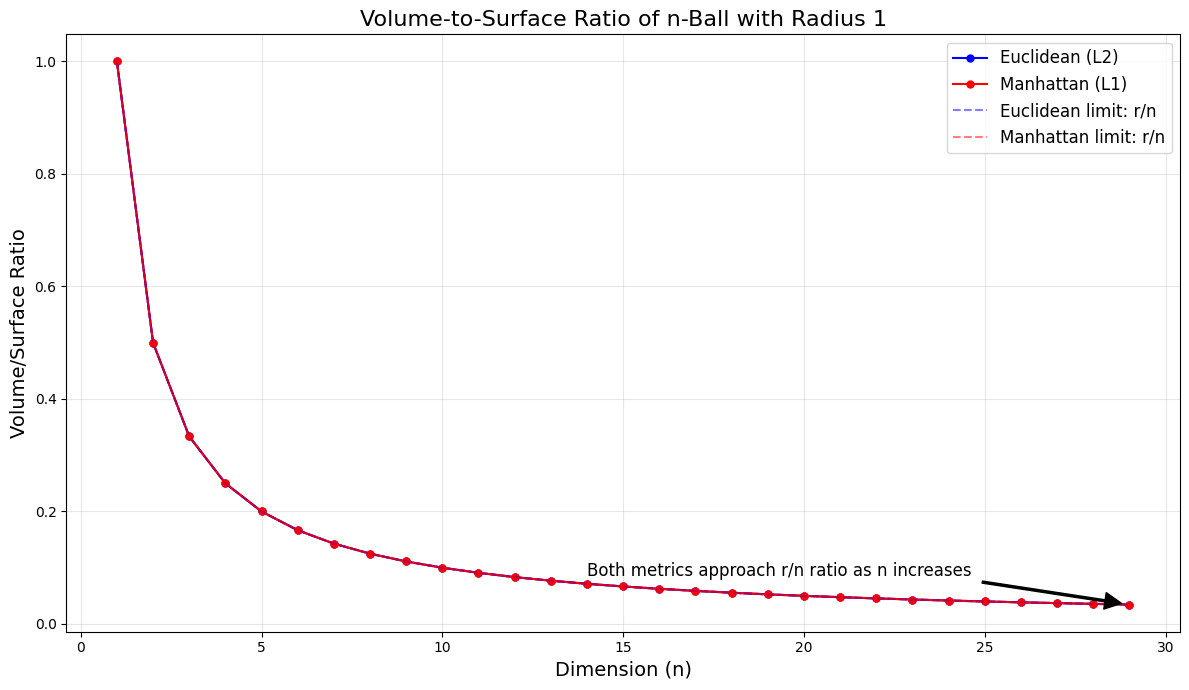

Maximum volume occurs at dimension n ≈ 5.2425
Maximum volume value: 5.277724

Volume-to-Surface ratio approaches r/n as n increases:
n = 5: Actual ratio = 0.200000, Theoretical r/n = 0.200000, Difference = -0.0000%
n = 10: Actual ratio = 0.100000, Theoretical r/n = 0.100000, Difference = 0.0000%
n = 20: Actual ratio = 0.050000, Theoretical r/n = 0.050000, Difference = -0.0000%
n = 50: Theoretical r/n = 0.020000
n = 100: Theoretical r/n = 0.010000
Euclidean space: Maximum volume occurs at dimension n ≈ 5.2645
Euclidean space: Maximum volume value: 5.277756
Manhattan space: Maximum volume occurs at dimension n ≈ 1.4950
Manhattan space: Maximum volume value: 2.127786
=== COMPARATIVE SUMMARY: EUCLIDEAN VS MANHATTAN ===

Euclidean space: Maximum volume at dimension n ≈ 5.2645, value: 5.277756
Manhattan space: Maximum volume at dimension n ≈ 1.4950, value: 2.127786

Euclidean: 50.0% of volume in outer 1% shell at n ≈ 100
Manhattan: 50.0% of volume in outer 1% shell at n ≈ 100

Euclidean: 90.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gamma, loggamma
from matplotlib.ticker import MaxNLocator

# Function to calculate the logarithm of the volume of an n-dimensional ball with radius r
def log_n_ball_volume(n, r):
    return (n/2) * np.log(np.pi) + n * np.log(r) - loggamma(n/2 + 1)

# Calculate actual volume (may underflow for large n)
def n_ball_volume(n, r):
    return np.exp(log_n_ball_volume(n, r))

# Calculate the volume of the crust using logarithms
def crust_volume(n, r):
    outer_vol = n_ball_volume(n, r)
    inner_vol = n_ball_volume(n, 0.99 * r)
    return outer_vol - inner_vol

# More numerically stable crust ratio calculation
def crust_ratio(n, r, shell_thickness=0.01):
    # For high dimensions, the ratio approaches 1-(1-thickness)^n
    # This is more stable than calculating volumes separately
    return 1 - (1 - shell_thickness)**n

# Add these functions to your existing code
def n_ball_surface(n, r):
    """Calculate surface area of an n-dimensional ball with radius r"""
    return (2 * np.pi**(n/2) * r**(n-1)) / gamma(n/2)

# Function to calculate volume of an n-ball in Manhattan space (L1 norm)
def manhattan_n_ball_volume(n, r):
    """Calculate the volume of an n-dimensional ball with radius r in Manhattan (L1) space"""
    # Formula: V(r) = (2^n * r^n) / n!
    return (2**n * r**n) / np.math.factorial(n)

# To handle larger values of n without factorial overflow
def log_manhattan_n_ball_volume(n, r):
    """Calculate log volume of n-dimensional Manhattan ball using Stirling's approximation for large n"""
    if n <= 20:
        return np.log(manhattan_n_ball_volume(n, r))
    else:
        # Using log(n!) ≈ n*log(n) - n + O(log(n)) (Stirling's approximation)
        log_factorial = n * np.log(n) - n + 0.5 * np.log(2 * np.pi * n)
        return n * np.log(2) + n * np.log(r) - log_factorial

# Add Manhattan surface area and crust calculation
def manhattan_n_ball_surface(n, r):
    """Surface area of an n-dimensional Manhattan ball with radius r"""
    # The formula for Manhattan ball surface area
    return (2**n * n * r**(n-1)) / np.math.factorial(n)

# Add a logarithmic version for high dimensions
def log_manhattan_n_ball_surface(n, r):
    """Calculate log surface area of n-dimensional Manhattan ball using Stirling for large n"""
    if n <= 20:
        return np.log(manhattan_n_ball_surface(n, r))
    else:
        # Using log(n!) ≈ n*log(n) - n + O(log(n)) (Stirling's approximation)
        log_factorial = n * np.log(n) - n + 0.5 * np.log(2 * np.pi * n)
        return n * np.log(2) + np.log(n) + (n-1) * np.log(r) - log_factorial

def manhattan_crust_volume(n, r, thickness=0.01):
    """Volume of the crust for Manhattan ball"""
    inner_radius = (1-thickness) * r
    return manhattan_n_ball_volume(n, r) - manhattan_n_ball_volume(n, inner_radius)

def manhattan_crust_ratio(n, r, thickness=0.01):
    """Ratio of crust to total volume for Manhattan ball - stable formula"""
    return 1 - (1-thickness)**n

# Dimensions to analyze
dimensions = [2, 3, 4, 5, 10, 20, 40, 50, 100, 200, 300, 400, 500]
radius = 1.0  # Unit ball

# Calculate volumes and ratios
volumes = []
crust_volumes = []
ratios = []

for n in dimensions:
    # For low dimensions, use direct calculation
    if n < 100:
        vol = n_ball_volume(n, radius)
        crust_vol = crust_volume(n, radius)
        ratio = crust_vol / vol
    # For high dimensions, use more stable approach
    else:
        vol = n_ball_volume(n, radius) if n < 300 else np.nan  # Still show volume when possible
        crust_vol = np.nan if n >= 300 else crust_volume(n, radius)
        ratio = crust_ratio(n, radius)  # This is stable for all dimensions
    
    volumes.append(vol)
    crust_volumes.append(crust_vol)
    ratios.append(ratio)

# Calculate Manhattan ball volumes for comparison
manhattan_volumes = []
for n in dimensions:
    if n <= 20:
        m_vol = manhattan_n_ball_volume(n, radius)
    else:
        m_vol = np.exp(log_manhattan_n_ball_volume(n, radius))
    manhattan_volumes.append(m_vol)

# Calculate Manhattan crust volumes and ratios
manhattan_crust_volumes = []
manhattan_ratios = []

for n in dimensions:
    if n <= 20:
        m_vol = manhattan_n_ball_volume(n, radius)
        m_crust = manhattan_crust_volume(n, radius)
        m_ratio = m_crust / m_vol
    else:
        m_vol = np.exp(log_manhattan_n_ball_volume(n, radius))
        m_ratio = manhattan_crust_ratio(n, radius)
        m_crust = m_ratio * m_vol
    
    manhattan_crust_volumes.append(m_crust)
    manhattan_ratios.append(m_ratio)

# Print results
for i, n in enumerate(dimensions):
    vol = volumes[i]
    crust_vol = crust_volumes[i]
    ratio = ratios[i]
    
    if np.isnan(vol) or np.isnan(crust_vol):
        print(f"Dimension {n}:")
        print(f"  Total volume: [too small for floating point]")
        print(f"  Crust volume: [too small for floating point]")
        print(f"  Ratio: {ratio:.6f} ({ratio*100:.4f}%)")
    else:
        print(f"Dimension {n}:")
        print(f"  Total volume: {vol:.6e}")
        print(f"  Crust volume: {crust_vol:.6e}")
        print(f"  Ratio: {ratio:.6f} ({ratio*100:.4f}%)")
    print()

# Add Manhattan volume to your results section
print("\nComparison of Euclidean vs. Manhattan n-ball volumes:")
for i, n in enumerate(dimensions):
    if i < 10:  # Print first 10 for readability
        print(f"Dimension {n}:")
        print(f"  Euclidean volume: {volumes[i]:.6e}")
        print(f"  Manhattan volume: {manhattan_volumes[i]:.6e}")
        print(f"  Ratio (Euclidean/Manhattan): {volumes[i]/manhattan_volumes[i]:.6f}")
        print()

# Plot the results
plt.figure(figsize=(12, 8))

# Plot ratio vs dimension
plt.subplot(2, 2, 1)
plt.plot(dimensions, ratios, 'bo-')
plt.xlabel('Dimension')
plt.ylabel('Crust Volume / Total Volume')
plt.title('Ratio of Crust Volume to Total Volume')
plt.grid(True)

# Log scale plot for better visualization
plt.subplot(2, 2, 2)
plt.semilogx(dimensions, ratios, 'ro-')
plt.xlabel('Dimension (log scale)')
plt.ylabel('Crust Volume / Total Volume')
plt.title('Ratio (Log Scale for Dimension)')
plt.grid(True)

# Plot total volumes
plt.subplot(2, 2, 3)
plt.plot(dimensions, volumes, 'go-')
plt.xlabel('Dimension')
plt.ylabel('Volume')
plt.title('Total Volume of n-dimensional Ball')
plt.yscale('log')
plt.grid(True)

# Plot ratio as percentage
plt.subplot(2, 2, 4)
plt.plot(dimensions, [r*100 for r in ratios], 'mo-')
plt.xlabel('Dimension')
plt.ylabel('Percentage (%)')
plt.title('Crust Volume as Percentage of Total Volume')
plt.grid(True)

plt.tight_layout()
plt.show()

# Update the volume plot to include Manhattan volumes
plt.figure(figsize=(12, 8))
plt.plot(dimensions, volumes, 'bo-', label='Euclidean (L2) Volume')
plt.plot(dimensions, manhattan_volumes, 'ro-', label='Manhattan (L1) Volume')
plt.yscale('log')
plt.xlabel('Dimension (n)', fontsize=12)
plt.ylabel('Volume (log scale)', fontsize=12)
plt.title('Comparison of n-Ball Volumes in Different Metrics (r=1)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Alternative visualization focusing on the ratio
plt.figure(figsize=(10, 6))
plt.plot(dimensions, [r*100 for r in ratios], 'ro-', linewidth=2)
plt.axhline(y=99, color='blue', linestyle='--', alpha=0.7, label='99%')
plt.xlabel('Dimension', fontsize=12)
plt.ylabel('Crust Volume / Total Volume (%)', fontsize=12)
plt.title('Evolution of Crust/Total Volume Ratio with Dimension', fontsize=14)
plt.grid(True)
plt.legend()
plt.xscale('log')
plt.gca().xaxis.set_major_formatter(plt.ScalarFormatter())
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

# Update the 4-panel plot to include both metrics
plt.figure(figsize=(16, 12))

# Panel 1: Crust ratio vs dimension
plt.subplot(2, 2, 1)
plt.plot(dimensions, ratios, 'bo-', label='Euclidean (L2)')
plt.plot(dimensions, manhattan_ratios, 'ro-', label='Manhattan (L1)')
plt.xlabel('Dimension', fontsize=12)
plt.ylabel('Crust Volume / Total Volume', fontsize=12)
plt.title('Ratio of Crust Volume to Total Volume', fontsize=14)
plt.grid(True)
plt.legend()

# Panel 2: Log scale plot for better visualization
plt.subplot(2, 2, 2)
plt.semilogx(dimensions, ratios, 'bo-', label='Euclidean (L2)')
plt.semilogx(dimensions, manhattan_ratios, 'ro-', label='Manhattan (L1)')
plt.xlabel('Dimension (log scale)', fontsize=12)
plt.ylabel('Crust Volume / Total Volume', fontsize=12)
plt.title('Ratio (Log Scale for Dimension)', fontsize=14)
plt.grid(True)
plt.legend()

# Panel 3: Total volumes
plt.subplot(2, 2, 3)
plt.plot(dimensions, volumes, 'bo-', label='Euclidean (L2)')
plt.plot(dimensions, manhattan_volumes, 'ro-', label='Manhattan (L1)')
plt.xlabel('Dimension', fontsize=12)
plt.ylabel('Volume', fontsize=12)
plt.title('Total Volume of n-dimensional Ball', fontsize=14)
plt.yscale('log')
plt.grid(True)
plt.legend()

# Panel 4: Ratio as percentage
plt.subplot(2, 2, 4)
plt.plot(dimensions, [r*100 for r in ratios], 'bo-', label='Euclidean (L2)')
plt.plot(dimensions, [r*100 for r in manhattan_ratios], 'ro-', label='Manhattan (L1)')
plt.xlabel('Dimension', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.title('Crust Volume as Percentage of Total Volume', fontsize=14)
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

# Enhanced visualization of the crust ratio
plt.figure(figsize=(12, 7))
plt.plot(dimensions, [r*100 for r in ratios], 'bo-', linewidth=2, label='Euclidean (L2)')
plt.plot(dimensions, [r*100 for r in manhattan_ratios], 'ro-', linewidth=2, label='Manhattan (L1)')
plt.axhline(y=99, color='green', linestyle='--', alpha=0.7, label='99% Threshold')
plt.xlabel('Dimension', fontsize=14)
plt.ylabel('Crust Volume / Total Volume (%)', fontsize=14)
plt.title('Concentration of Volume in the Outer 1% Shell', fontsize=16)
plt.grid(True)
plt.legend(fontsize=12)
plt.xscale('log')
plt.gca().xaxis.set_major_formatter(plt.ScalarFormatter())
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

# After your existing code, add these new analyses:

# 1. Maximum Volume Dimension Analysis
# -----------------------------------
# Use a finer grid to find precisely where volume peaks
fine_dims = np.linspace(1, 30, 500)
fine_volumes = [n_ball_volume(n, radius) for n in fine_dims]

# Find the maximum volume and corresponding dimension
max_vol_idx = np.argmax(fine_volumes)
max_vol_dim = fine_dims[max_vol_idx]
max_vol = fine_volumes[max_vol_idx]

# Plot the volume as a function of dimension
plt.figure(figsize=(10, 6))
plt.plot(fine_dims, fine_volumes, 'b-')
plt.scatter([max_vol_dim], [max_vol], color='red', s=100, zorder=10, 
            label=f'Maximum at n≈{max_vol_dim:.2f}')
plt.grid(True, alpha=0.3)
plt.title('Volume of n-Ball with Radius 1 as a Function of Dimension', fontsize=14)
plt.xlabel('Dimension (n)', fontsize=12)
plt.ylabel('Volume', fontsize=12)
plt.legend(fontsize=12)
plt.annotate(f'Max Volume: {max_vol:.4f}', 
             xy=(max_vol_dim, max_vol),
             xytext=(max_vol_dim+3, max_vol),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1.5),
             fontsize=12)
plt.tight_layout()
plt.show()

# Fine-dimension analysis to find where the maximum volume occurs for both metrics
fine_dims = np.linspace(1, 20, 500)
fine_euc_volumes = [n_ball_volume(n, radius) for n in fine_dims]
fine_man_volumes = []
for n in fine_dims:
    if n.is_integer() and int(n) <= 20:
        m_vol = manhattan_n_ball_volume(int(n), radius)
    else:
        # For non-integer dimensions, interpolate factorial
        from scipy.special import gamma
        m_vol = (2**n * radius**n) / gamma(n+1)
    fine_man_volumes.append(m_vol)

# Find maxima
max_euc_idx = np.argmax(fine_euc_volumes)
max_euc_dim = fine_dims[max_euc_idx]
max_euc_vol = fine_euc_volumes[max_euc_idx]

max_man_idx = np.argmax(fine_man_volumes)
max_man_dim = fine_dims[max_man_idx]
max_man_vol = fine_man_volumes[max_man_idx]

# Plot the maxima
plt.figure(figsize=(12, 8))
plt.plot(fine_dims, fine_euc_volumes, 'b-', label='Euclidean (L2) Volume')
plt.plot(fine_dims, fine_man_volumes, 'r-', label='Manhattan (L1) Volume')
plt.scatter([max_euc_dim], [max_euc_vol], color='blue', s=100, zorder=10, 
            marker='*', label=f'Euclidean Max at n≈{max_euc_dim:.2f}')
plt.scatter([max_man_dim], [max_man_vol], color='red', s=100, zorder=10,
            marker='*', label=f'Manhattan Max at n≈{max_man_dim:.2f}')
plt.grid(True, alpha=0.3)
plt.title('Volume of Unit n-Ball: Euclidean vs. Manhattan Metrics', fontsize=14)
plt.xlabel('Dimension (n)', fontsize=12)
plt.ylabel('Volume', fontsize=12)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

# 2. Volume-to-Surface Ratio Analysis
# -----------------------------------
# Calculate surface area and volume-to-surface ratio for each dimension
regular_dims = np.arange(1, 30)
volumes_regular = [n_ball_volume(n, radius) for n in regular_dims]
surfaces = [n_ball_surface(n, radius) for n in regular_dims]
vol_to_surface_ratios = [v/s for v, s in zip(volumes_regular, surfaces)]

# Calculate Manhattan volume-to-surface ratio
manhattan_surface_areas = []
manhattan_vol_to_surface_ratios = []

for n in regular_dims:
    if n <= 20:
        m_vol = manhattan_n_ball_volume(n, radius)
        m_surf = manhattan_n_ball_surface(n, radius) 
    else:
        m_vol = np.exp(log_manhattan_n_ball_volume(n, radius))
        # Use the logarithmic version for consistent high-dimensional calculations
        m_surf = np.exp(log_manhattan_n_ball_surface(n, radius))
    
    manhattan_surface_areas.append(m_surf)
    manhattan_vol_to_surface_ratios.append(m_vol/m_surf)

# Plot volume-to-surface ratio
plt.figure(figsize=(10, 6))
plt.plot(regular_dims, vol_to_surface_ratios, 'g-o', markersize=6)
plt.grid(True, alpha=0.3)
plt.title('Volume-to-Surface Ratio of n-Ball with Radius 1', fontsize=14)
plt.xlabel('Dimension (n)', fontsize=12)
plt.ylabel('Volume/Surface Ratio', fontsize=12)

# Add observation about the ratio
plt.annotate(f'As n increases, ratio → r/n = {radius}/{regular_dims[-1]:.1f} = {radius/regular_dims[-1]:.4f}',
             xy=(regular_dims[-1], vol_to_surface_ratios[-1]),
             xytext=(regular_dims[-1]-15, vol_to_surface_ratios[-1]+0.1),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1.5),
             fontsize=12)

# Add the theoretical limit line
plt.axhline(y=0, color='r', linestyle='--', alpha=0.5, label='Limit as n→∞')
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

# Enhanced volume-to-surface ratio plot
plt.figure(figsize=(12, 7))
plt.plot(regular_dims, vol_to_surface_ratios, 'bo-', markersize=5, label='Euclidean (L2)')
plt.plot(regular_dims, manhattan_vol_to_surface_ratios, 'ro-', markersize=5, label='Manhattan (L1)')

# Add theoretical limit lines
plt.plot(regular_dims, [radius/n for n in regular_dims], 'b--', alpha=0.5, label='Euclidean limit: r/n')
plt.plot(regular_dims, [radius/n for n in regular_dims], 'r--', alpha=0.5, label='Manhattan limit: r/n')

plt.grid(True, alpha=0.3)
plt.title('Volume-to-Surface Ratio of n-Ball with Radius 1', fontsize=16)
plt.xlabel('Dimension (n)', fontsize=14)
plt.ylabel('Volume/Surface Ratio', fontsize=14)
plt.legend(fontsize=12)

# Add annotations
plt.annotate('Both metrics approach r/n ratio as n increases',
             xy=(regular_dims[-1], vol_to_surface_ratios[-1]),
             xytext=(regular_dims[-1]-15, vol_to_surface_ratios[-1]+0.05),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1.5),
             fontsize=12)

plt.tight_layout()
plt.show()

# Print the maximum volume dimension
print(f"Maximum volume occurs at dimension n ≈ {max_vol_dim:.4f}")
print(f"Maximum volume value: {max_vol:.6f}")
print("\nVolume-to-Surface ratio approaches r/n as n increases:")
for n in [5, 10, 20, 50, 100]:
    if n < 30:
        actual_ratio = vol_to_surface_ratios[n-1]
        theoretical = radius/n
        print(f"n = {n}: Actual ratio = {actual_ratio:.6f}, Theoretical r/n = {theoretical:.6f}, Difference = {(actual_ratio-theoretical)*100:.4f}%")
    else:
        theoretical = radius/n
        print(f"n = {n}: Theoretical r/n = {theoretical:.6f}")

# Print the maximum volume dimensions
print(f"Euclidean space: Maximum volume occurs at dimension n ≈ {max_euc_dim:.4f}")
print(f"Euclidean space: Maximum volume value: {max_euc_vol:.6f}")
print(f"Manhattan space: Maximum volume occurs at dimension n ≈ {max_man_dim:.4f}")
print(f"Manhattan space: Maximum volume value: {max_man_vol:.6f}")

# Print comparative summary
print("=== COMPARATIVE SUMMARY: EUCLIDEAN VS MANHATTAN ===\n")

# Maximum volume dimensions
print(f"Euclidean space: Maximum volume at dimension n ≈ {max_euc_dim:.4f}, value: {max_euc_vol:.6f}")
print(f"Manhattan space: Maximum volume at dimension n ≈ {max_man_dim:.4f}, value: {max_man_vol:.6f}\n")

# Dimension where crust ratio exceeds 50%, 90%, 99%
for threshold in [0.5, 0.9, 0.99]:
    euc_idx = next((i for i, r in enumerate(ratios) if r > threshold), None)
    man_idx = next((i for i, r in enumerate(manhattan_ratios) if r > threshold), None)
    
    if euc_idx is not None:
        print(f"Euclidean: {threshold*100}% of volume in outer 1% shell at n ≈ {dimensions[euc_idx]}")
    
    if man_idx is not None:
        print(f"Manhattan: {threshold*100}% of volume in outer 1% shell at n ≈ {dimensions[man_idx]}")
    
    print()

# Volume-to-Surface ratio comparison
print("Volume-to-Surface ratio comparison:")
for n in [2, 5, 10, 20]:
    idx = n - regular_dims[0]
    euc_ratio = vol_to_surface_ratios[idx]
    man_ratio = manhattan_vol_to_surface_ratios[idx]
    theoretical = radius/n
    
    print(f"n = {n}:")
    print(f"  Euclidean: {euc_ratio:.6f}, Manhattan: {man_ratio:.6f}, Theoretical r/n: {theoretical:.6f}")
    print(f"  Difference from r/n: Euclidean {(euc_ratio-theoretical)*100:.2f}%, Manhattan {(man_ratio-theoretical)*100:.2f}%")
    print()